### ИМПОРТ БИБЛИОТЕК

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.linalg import eigh
from scipy.linalg import eig
from scipy.interpolate import CubicSpline
import math
import pandas as pd

### ГЕОМЕТРИЯ И МАТЕРИАЛ

In [2]:
Ls = 1.8                   # Длина вала, м
d = 0.04                   # Диаметр вала, м
D = 0.3                    # Диаметр диска, м
h = 0.05                   # Ширина диска, м
z_disk = Ls * 0.2          # Положение диска вдоль вала, м
ro = 7800                  # Плотность материала, кг/м³
E = 2.1e11                 # Модуль Юнга, Па

# Геометрические характеристики сечения
A = np.pi * d**2 / 4       # Площадь сечения, м²
Ix = np.pi * d**4 / 64     # Момент инерции относительно X, м⁴
Iy = Ix                    # Момент инерции относительно Y, м⁴
Ip = np.pi * d**4 / 32     # Полярный момент инерции, м⁴


### ПАРАМЕТРЫ КОНЕЧНО-ЭЛЕМЕНТНОЙ СЕТКИ

In [3]:
n_elems = 10                         # Количество конечных элементов
n_nodes = n_elems + 1                # Количество узлов
L = Ls / n_elems                     # Длина одного конечного элемента, м
mu = ro * A * Ls / (n_elems * L)     # Распределенная масса конечного элемента, кг/м

### Проверка соотношения L/d

In [4]:
ratio = L / d
print("=" * 50)
print(f"ПАРАМЕТРЫ МОДЕЛИ")
print("=" * 50)
print(f"L/d = {ratio:.2f} (рекомендуемый диапазон: 4-5)")

ПАРАМЕТРЫ МОДЕЛИ
L/d = 4.50 (рекомендуемый диапазон: 4-5)


### МАТРИЦА ЖЕСТКОСТИ КОНЕЧНОГО ЭЛЕМЕНТА

In [5]:
def element_stiffness_matrix(E: float, Ix: float, Iy: float, L: float) -> np.ndarray:
    factor = E / L**3
    
    # Изгиб в плоскости YZ (вокруг оси X)
    k_yz = factor * Ix * np.array([
        [12,   -6*L,  -12,   -6*L],
        [-6*L,  4*L**2,  6*L,  2*L**2],
        [-12,    6*L,   12,    6*L],
        [-6*L,  2*L**2,  6*L,  4*L**2]
    ])
    
    # Изгиб в плоскости XZ (вокруг оси Y)
    k_xz = factor * Iy * np.array([
        [12,    6*L,  -12,    6*L],
        [6*L,   4*L**2, -6*L,  2*L**2],
        [-12,   -6*L,   12,   -6*L],
        [6*L,   2*L**2, -6*L,  4*L**2]
    ])
    
    K = np.zeros((8, 8))
    xz_dofs = [0, 3, 4, 7]
    yz_dofs = [1, 2, 5, 6]
    
    K[np.ix_(yz_dofs, yz_dofs)] = k_yz
    K[np.ix_(xz_dofs, xz_dofs)] = k_xz
    
    return K

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ ЖЕСТКОСТИ

In [6]:
def assemble_global_stiffness(K_element: np.ndarray, 
                              node1_idx: int, 
                              node2_idx: int, 
                              K_global: lil_matrix) -> lil_matrix:
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])
    
    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    K_global[rows, cols] += K_element
    
    return K_global


# Вычисление матрицы жесткости элемента (одинакова для всех элементов)
K_element = element_stiffness_matrix(E, Ix, Iy, L)

# Инициализация и сборка глобальной матрицы жесткости
n_dofs = 4 * n_nodes
K_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    K_global = assemble_global_stiffness(K_element, node1, node2, K_global)

K = K_global.toarray()
if hasattr(K_global, "toarray"):
    K_global = K_global.toarray()

print(f"\nГлобальная матрица жесткости: {K.shape}")
print(f"Макс. отклонение от симметрии: {np.max(np.abs(K - K.T)):.2e}")


Глобальная матрица жесткости: (44, 44)
Макс. отклонение от симметрии: 0.00e+00


### МАТРИЦА МАСС КОНЕЧНОГО ЭЛЕМЕНТА

In [7]:
# Масса и момент инерции диска
Md = ro * h * np.pi * D**2 / 4               # Масса диска, кг
Jd = Md * D**2 / 16 + Md * h**2 / 12         # Момент инерции диска, кг·м²

def element_mass_matrix(ro: float, A: float, L: float) -> np.ndarray:
    factor = ro * A * L / 420
    
    M = factor * np.array([
        [156,   0,   0,   22*L,   54,   0,   0,   -13*L],
        [0,  156,   -22*L,   0,   0,   54,   13*L,   0],
        [0,  -22*L,   4*L**2,   0,   0,   -13*L,   -3*L**2,   0],
        [22*L,   0,   0,   4*L**2,   13*L,   0,   0,   -3*L**2],
        [54,   0,   0,   13*L,   156,   0,   0,   -22*L],
        [0,  54,   -13*L,   0,   0,   156,   22*L,   0],
        [0,  13*L,   -3*L**2,   0,   0,   22*L,   4*L**2,   0],
        [-13*L,   0,   0,   -3*L**2,   -22*L,   0,   0,   4*L**2]
    ], dtype=float)
    
    return M

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ МАСС

In [8]:
def assemble_global_mass(M_element: np.ndarray,
                         node1_idx: int,
                         node2_idx: int,
                         M_global: lil_matrix) -> lil_matrix:
    """Сборка 8x8 матрицы массы элемента в глобальную матрицу."""
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])

    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    M_global[rows, cols] += M_element
    return M_global


# Матрица массы одного конечного элемента
M_element = element_mass_matrix(ro, A, L)

# Инициализация и сборка глобальной матрицы масс
n_dofs = 4 * n_nodes
M_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    M_global = assemble_global_mass(M_element, node1, node2, M_global)

# Добавление массы и моментов инерции диска в узел disk_node_idx
# Порядок СОС: Ux, Uy, Rx, Ry
disk_node_idx = 2
ux = 4 * disk_node_idx
uy = ux + 1
rx = ux + 2
ry = ux + 3

M_global[ux, ux] += Md
M_global[uy, uy] += Md
M_global[rx, rx] += Jd
M_global[ry, ry] += Jd

if hasattr(M_global, 'toarray'):
    M_global = M_global.toarray()

print(f"\nГлобальная матрица масс: {M_global.shape}")
print(f"Проверка ожидаемого размера 44x44: {M_global.shape == (44, 44)}")
print(f"Макс. отклонение от симметрии M: {np.max(np.abs(M_global - M_global.T)):.2e}")




Глобальная матрица масс: (44, 44)
Проверка ожидаемого размера 44x44: True
Макс. отклонение от симметрии M: 0.00e+00


### ПАРАМЕТРЫ ДИСБАЛАНСА И СИЛЫ НАГРУЗКИ

In [9]:
e = 0.1                     # Эксцентриситет, м
rpm = 3000                  # Частота вращения, об/мин
rot_freq_hz = rpm / 60       # Частота вращения, Гц
Omega = 2 * np.pi * rot_freq_hz  # Угловая скорость, рад/с
gamma = 0                   # Фаза дисбаланса, рад
g = 9.80665                 # Ускорение свободного падения, м/с²

def imbalance_force_vector(n_nodes: int, disk_node_idx: int, M_d: float, 
                          e: float, Omega: float, gamma: float = 0.0, 
                          g: float = 9.80665) -> np.ndarray:
    N = n_nodes * 4
    F = np.zeros((N, 1))
    
    Fx = M_d * e * Omega**2 * np.cos(gamma)
    Fy = M_d * e * Omega**2 * np.sin(gamma) - M_d * g
    
    base_idx = 4 * disk_node_idx
    F[base_idx, 0] = Fx      # Ux компонента
    F[base_idx + 1, 0] = Fy  # Uy компонента
    
    return F


F_imbalance = imbalance_force_vector(n_nodes, disk_node_idx, Md, e, Omega, gamma, g)
print(f"\nСила дисбаланса: X={F_imbalance[4*disk_node_idx, 0]:.2f} Н, Y={F_imbalance[4*disk_node_idx + 1, 0]:.2f} Н")


Сила дисбаланса: X=272080.08 Н, Y=-270.34 Н


### ГИРОСКОПИЧЕСКАЯ МАТРИЦА

In [10]:
Jzz = Md * D**2 / 8

def build_gyroscopic_matrix(n_nodes: int, disks: list) -> np.ndarray:
    ndof = n_nodes * 4
    G0 = np.zeros((ndof, ndof))
    
    for disk in disks:
        node = disk['node']
        Jp = disk['Jp']
        
        rx = 4 * node + 2  # Rx
        ry = 4 * node + 3  # Ry
        
        G0[rx, ry] += Jp
        G0[ry, rx] -= Jp
    
    return G0


disks = [{'node': 2, 'Jp': Jzz}]
G0 = build_gyroscopic_matrix(n_nodes, disks)
G = Omega * G0

print(f"\nГироскопическая матрица: {G.shape}")
print(f"Макс. отклонение от кососимметрии: {np.max(np.abs(G + G.T)):.2e}")


Гироскопическая матрица: (44, 44)
Макс. отклонение от кососимметрии: 0.00e+00


### МАТРИЦА ДЕМПФИРОВАНИЯ В ПОДШИПНИКАХ

In [11]:
def build_bearing_damping_matrix(n_nodes: int, c_b: float) -> np.ndarray:
    ndof = n_nodes * 4
    D_b = np.zeros((ndof, ndof))
    
    # Первый узел (узел 0)
    D_b[0, 0] = c_b   # Ux
    D_b[1, 1] = c_b   # Uy
    
    # Последний узел
    last_node = n_nodes - 1
    D_b[4*last_node, 4*last_node] = c_b      # Ux
    D_b[4*last_node + 1, 4*last_node + 1] = c_b  # Uy
    
    return D_b

c_b = 1e3  # Н·с/м
D_b = build_bearing_damping_matrix(n_nodes, c_b)
print(f"\nМатрица демпфирования: {D_b.shape}")


Матрица демпфирования: (44, 44)


### ГРАНИЧНЫЕ УСЛОВИЯ И РЕДУКЦИЯ МАТРИЦ

In [12]:
def build_bearing_stiffness_matrix(n_nodes: int, k_bx: float, k_by: float, bearing_nodes: list) -> np.ndarray:
    ndof = n_nodes * 4
    Kb = np.zeros((ndof, ndof))

    for node in bearing_nodes:
        ux = 4 * node
        uy = ux + 1
        Kb[ux, ux] += k_bx
        Kb[uy, uy] += k_by

    return Kb
    
bearing_nodes = [0, n_nodes - 1]
k_bx = 5e7   
k_by = 5e7

K_b = build_bearing_stiffness_matrix(n_nodes, k_bx, k_by, bearing_nodes)
K_global = K_global + K_b

In [13]:
fixed_dofs = np.array([], dtype=int)
n_dofs = 4 * n_nodes
free_dofs = np.arange(n_dofs)

# Берём подматрицы уже из плотных массивов
Kf = K_global[np.ix_(free_dofs, free_dofs)]
Mf = M_global[np.ix_(free_dofs, free_dofs)]

print(f"Размерность Kf: {Kf.shape}, Mf: {Mf.shape}")

Размерность Kf: (44, 44), Mf: (44, 44)


### РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ И ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ


РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ
Всего собственных частот: 44
Уникальных собственных частот: 44

ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ
----------------------------------------


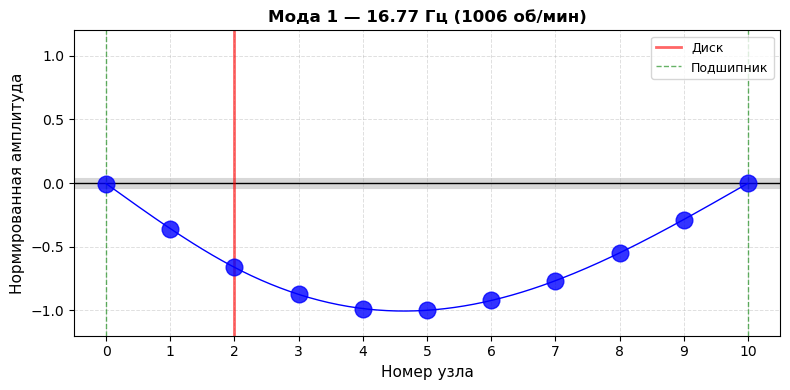

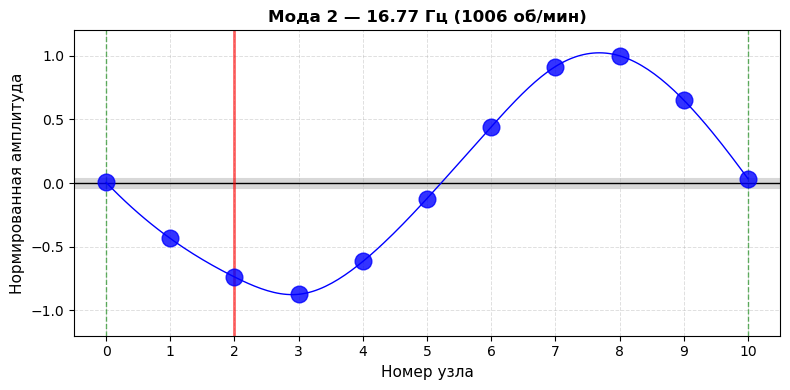

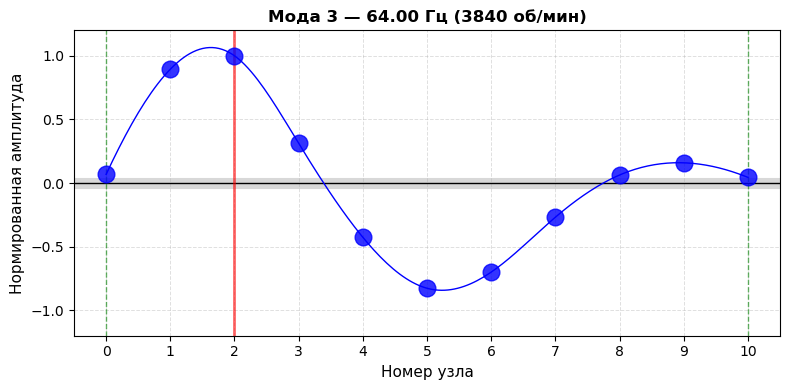

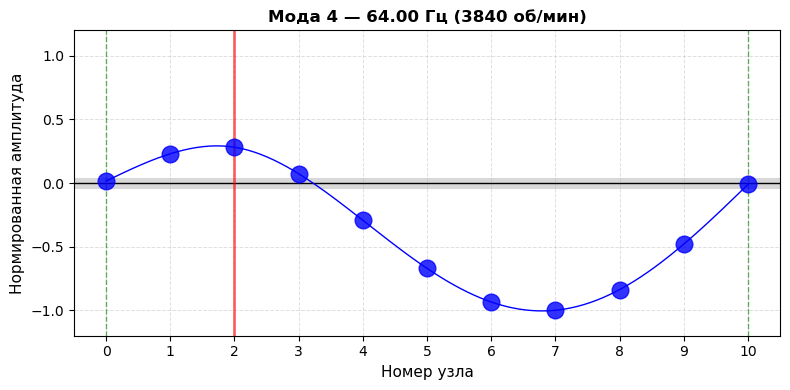

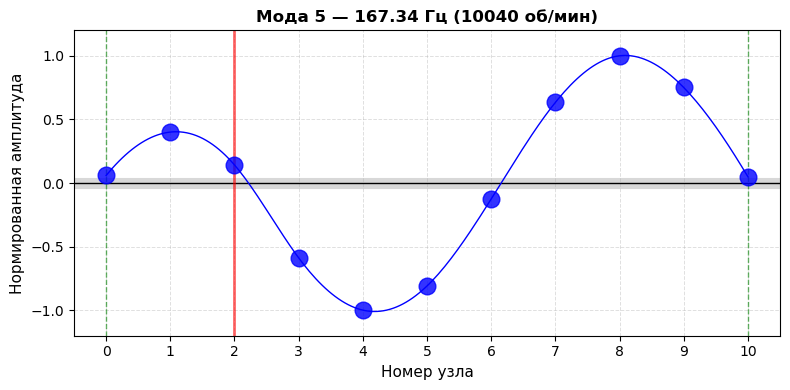

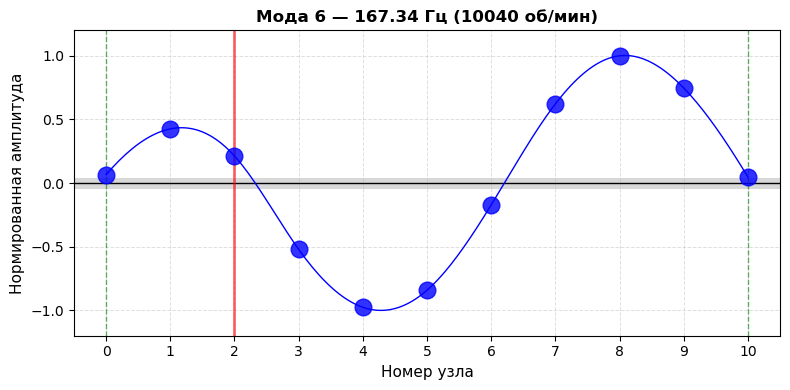

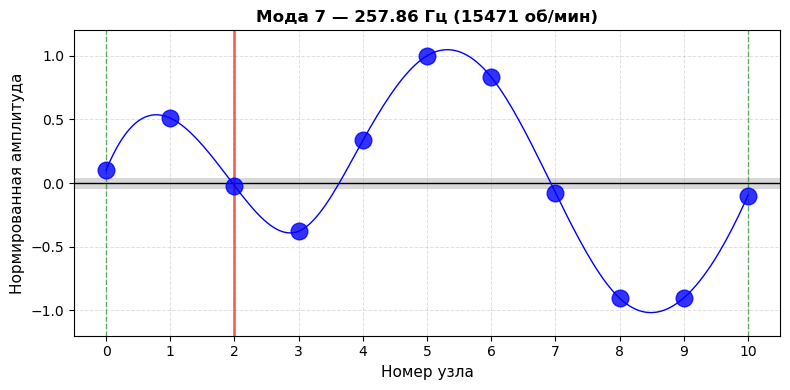

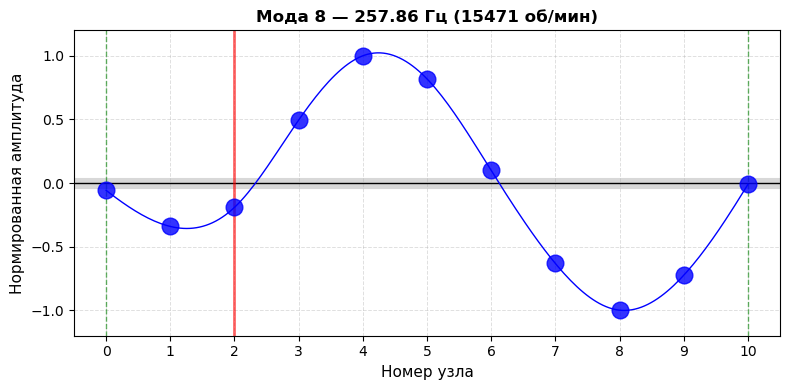

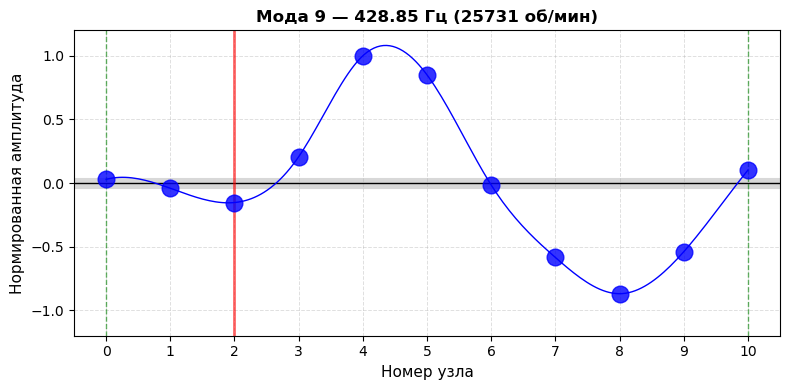

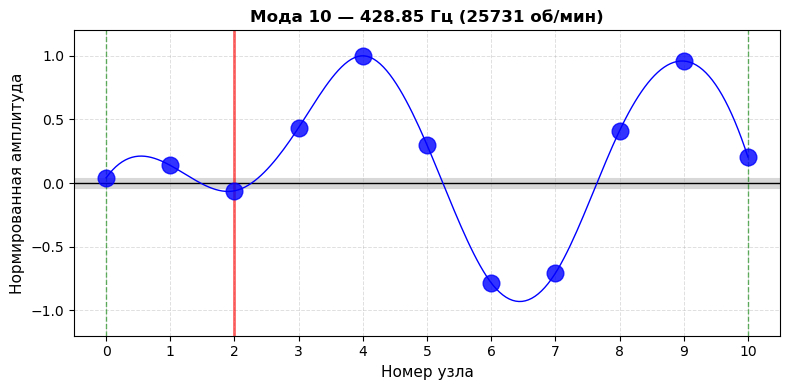

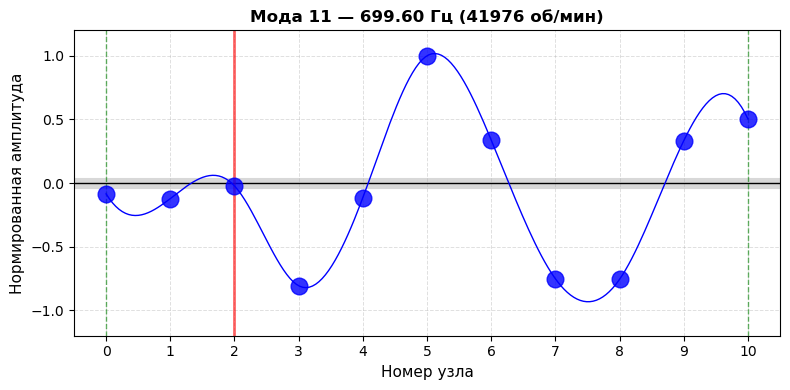

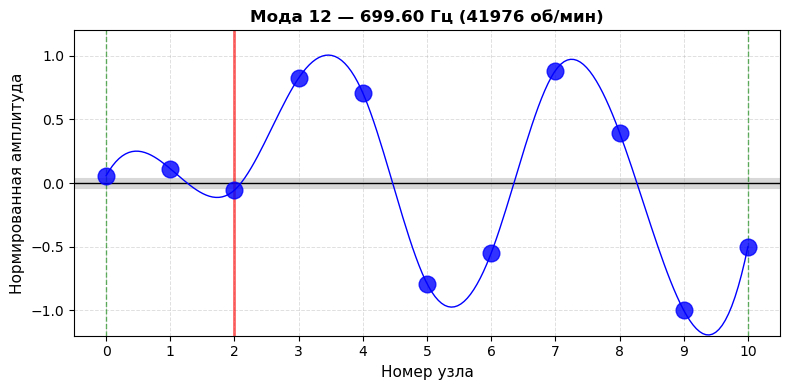

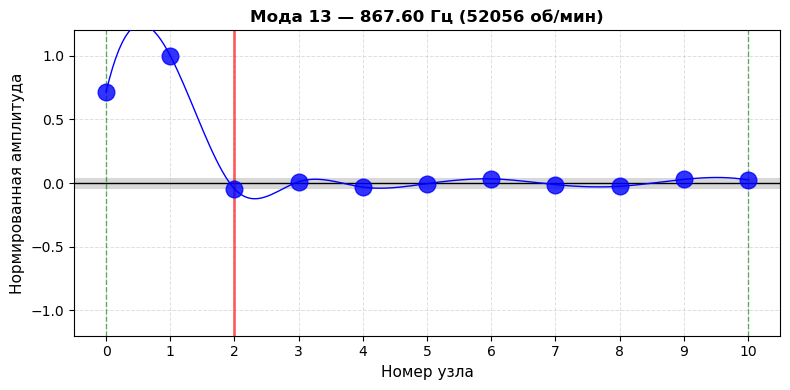

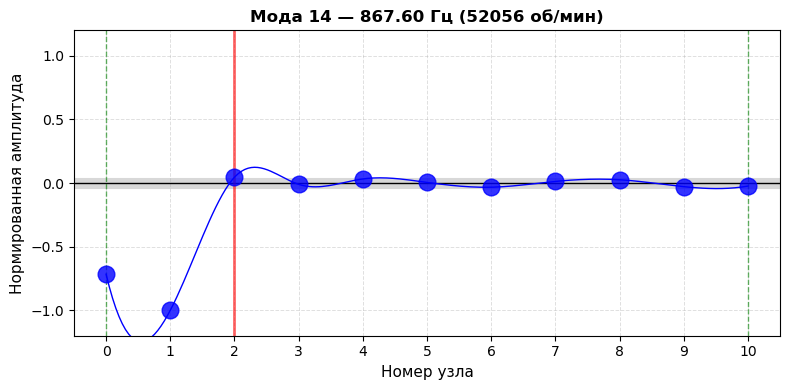

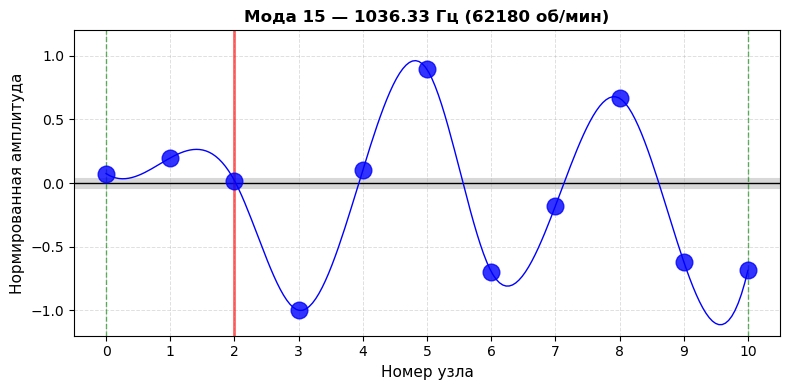

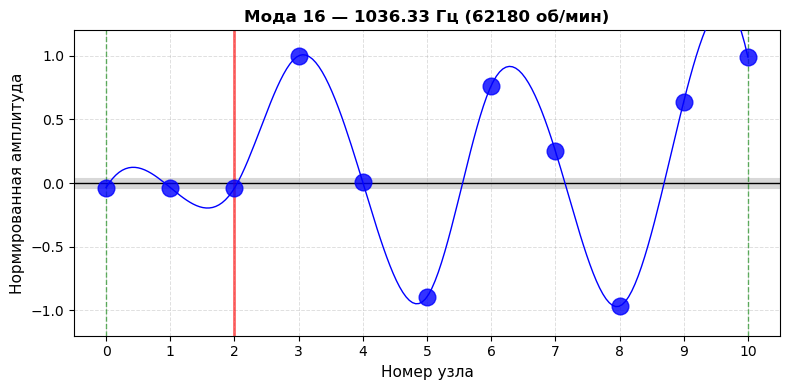

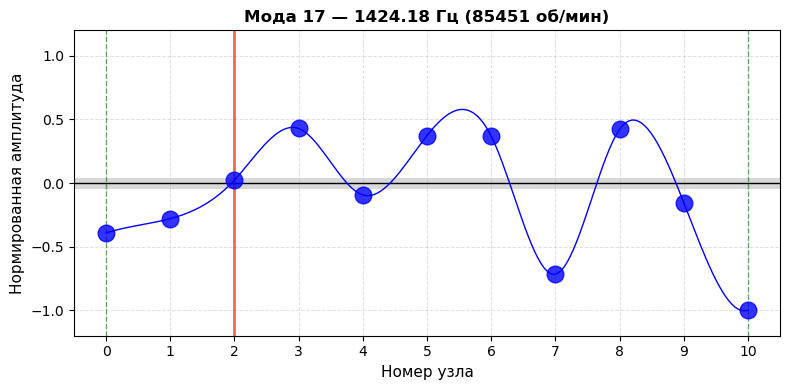

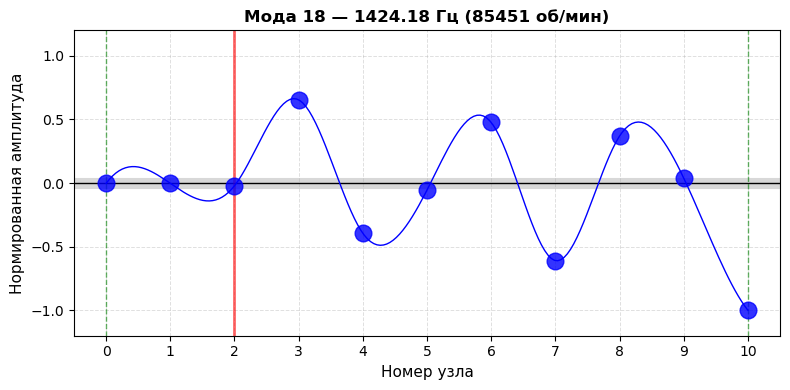

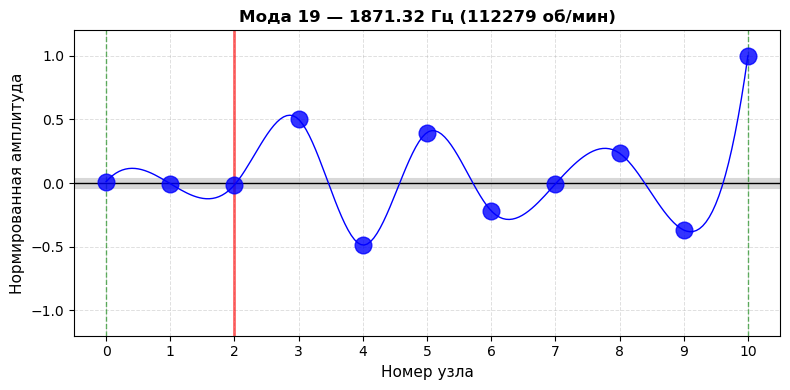

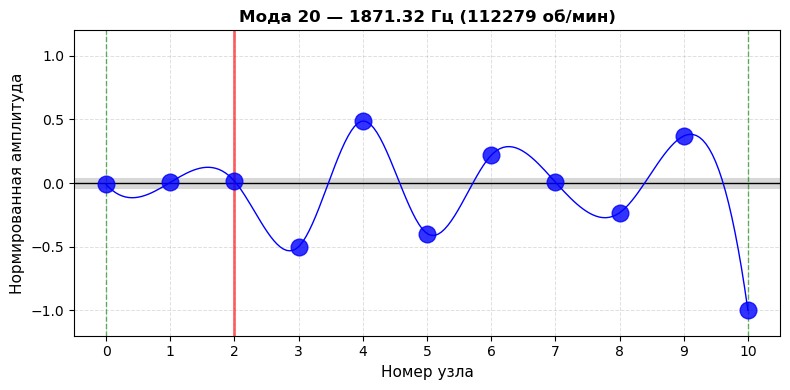

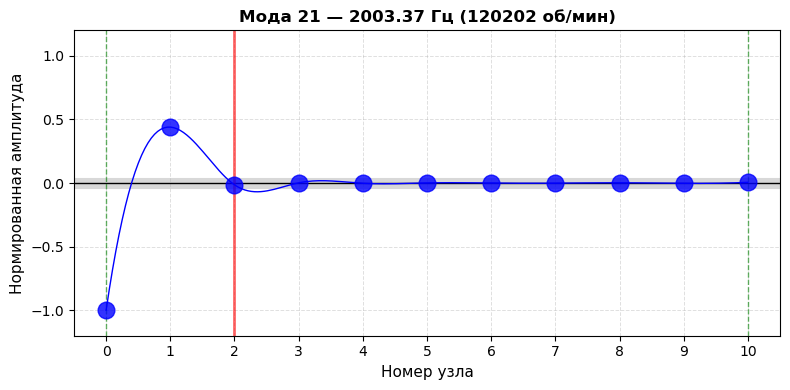

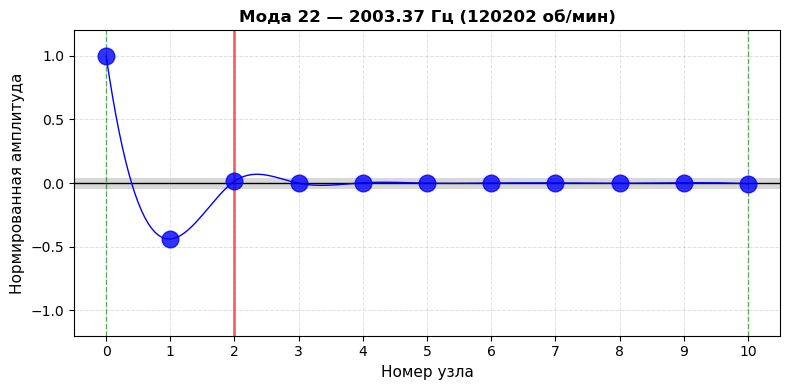

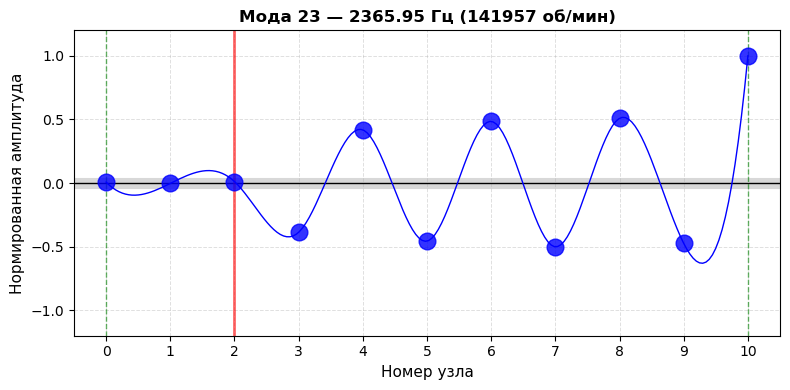

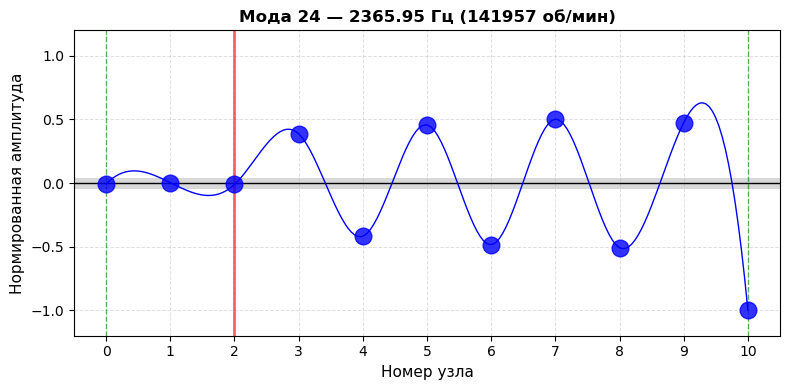

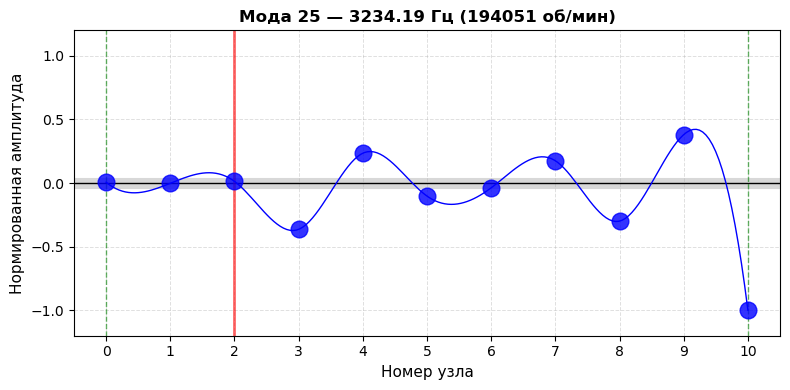

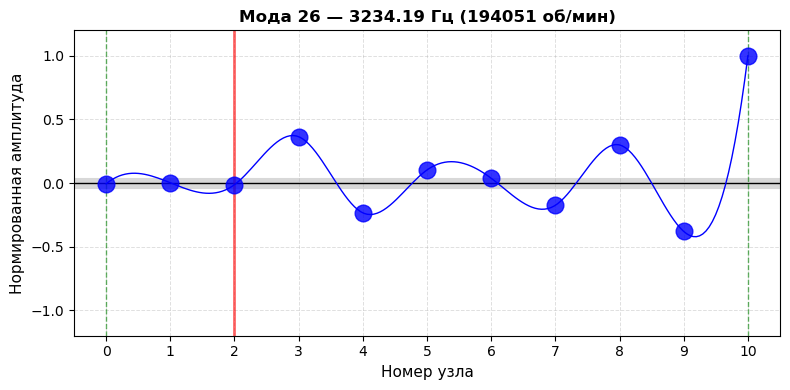

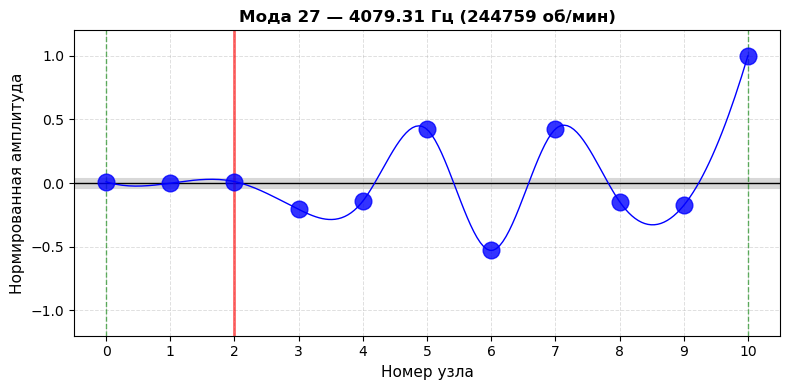

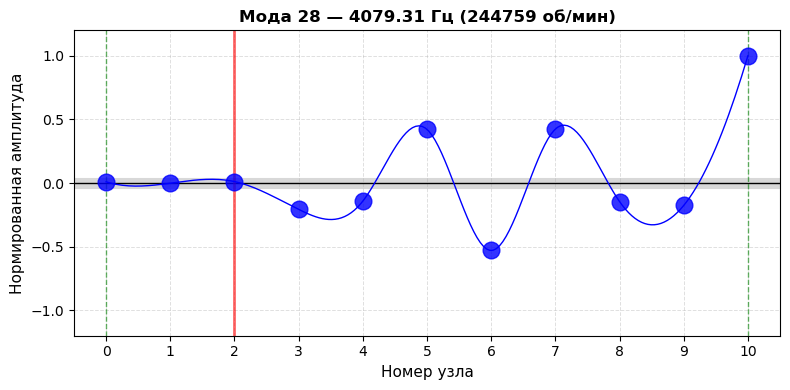

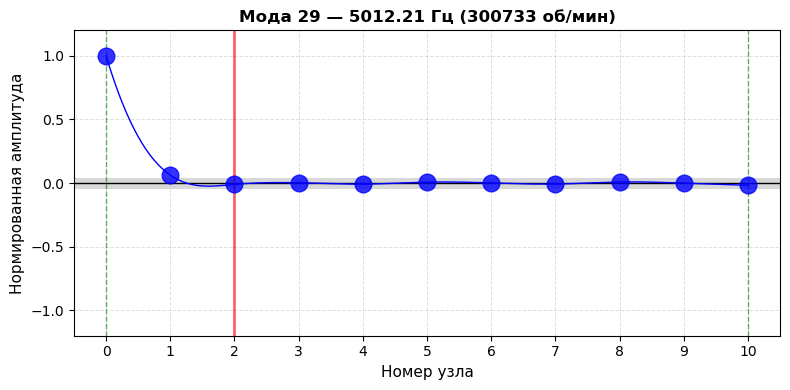

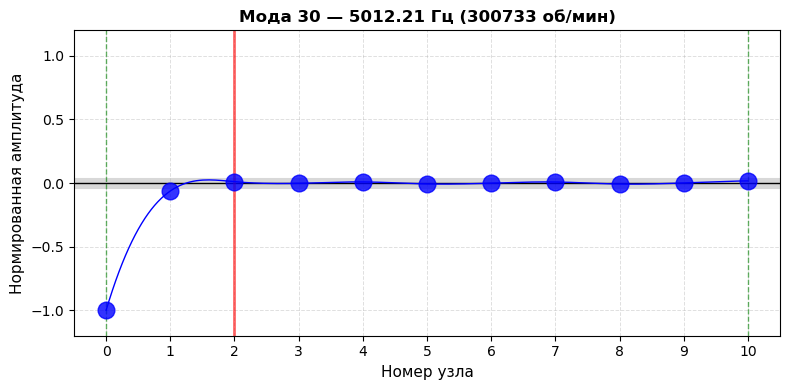

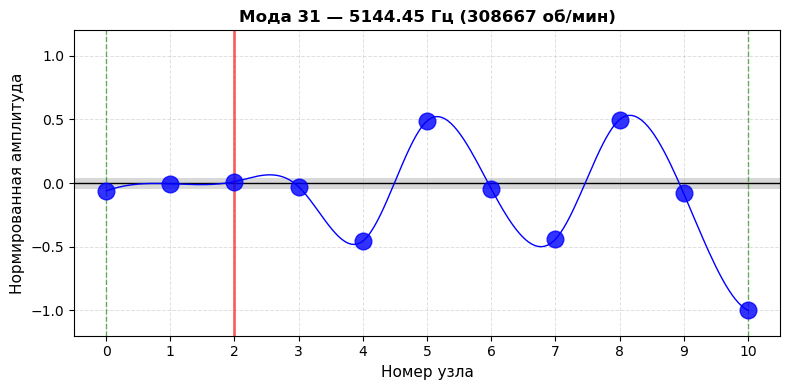

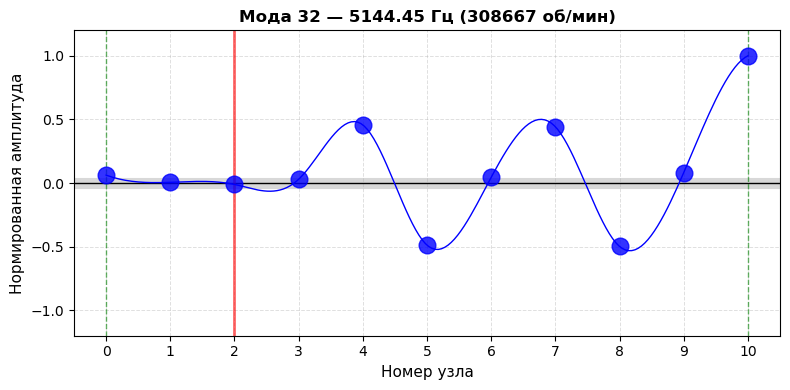

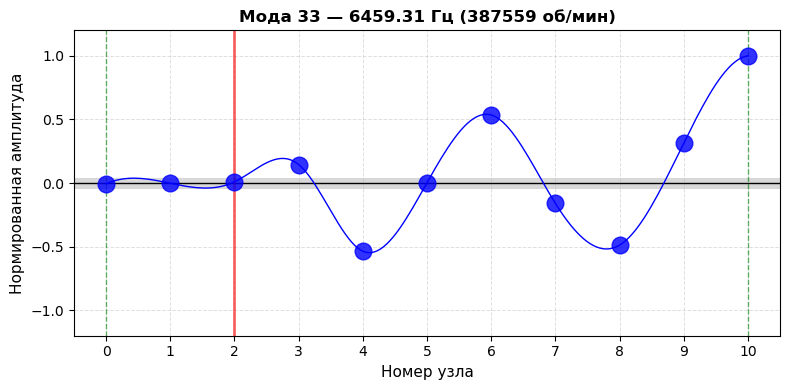

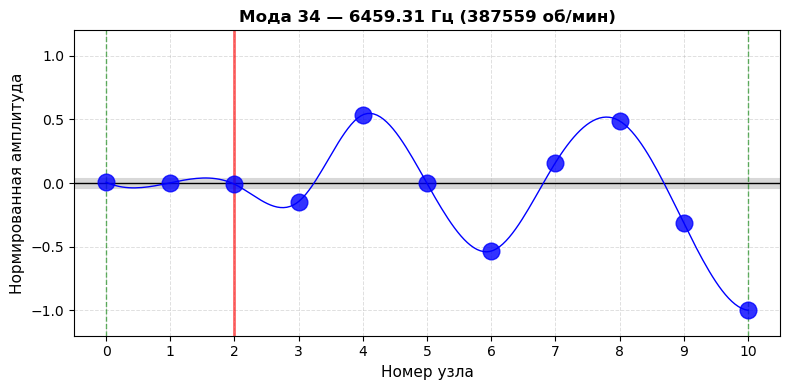

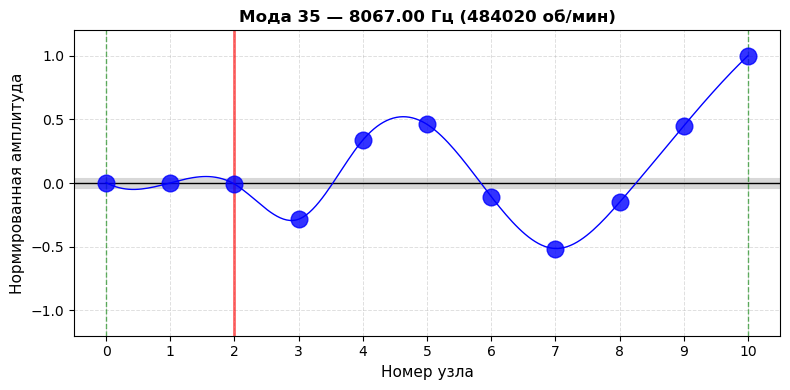

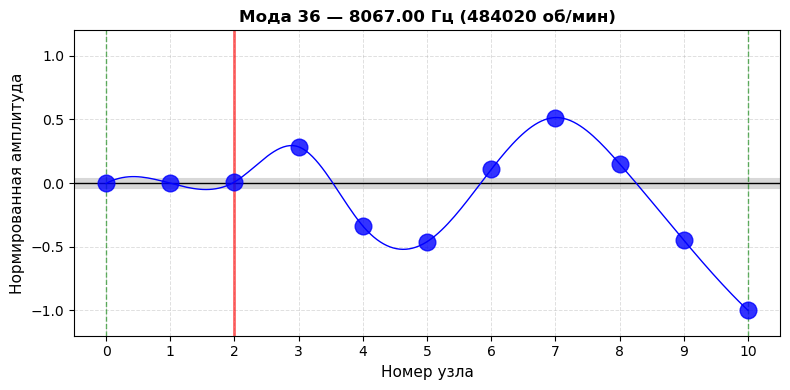

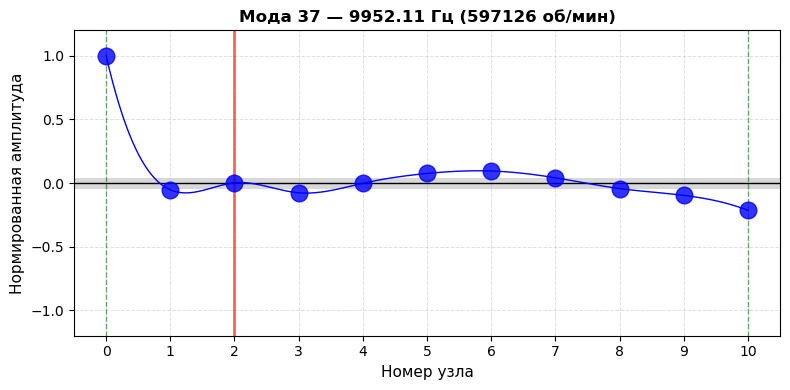

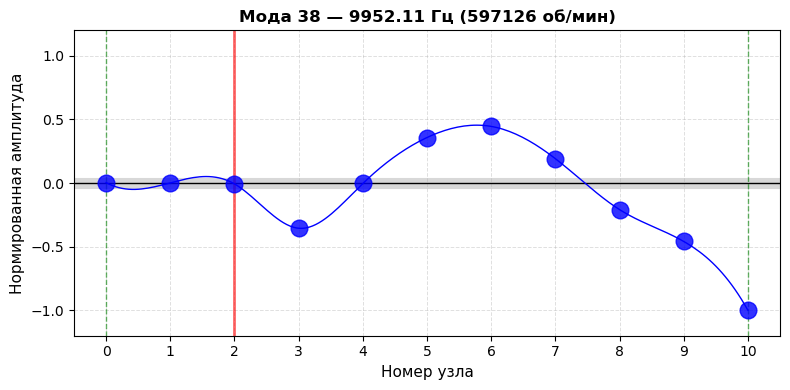

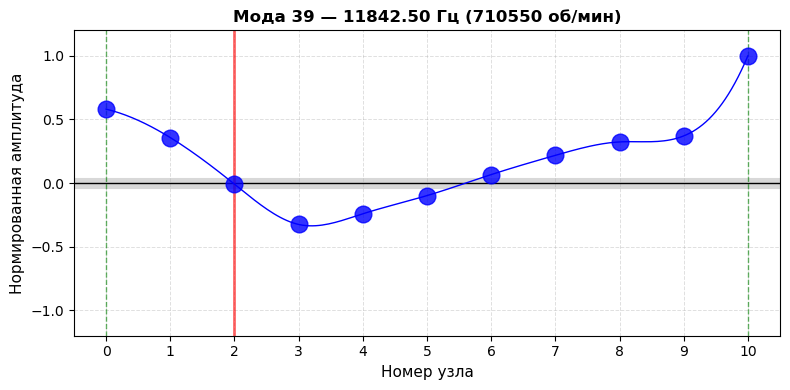

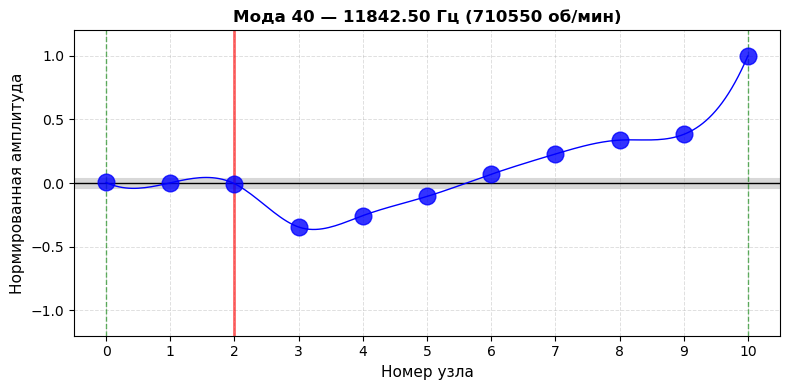

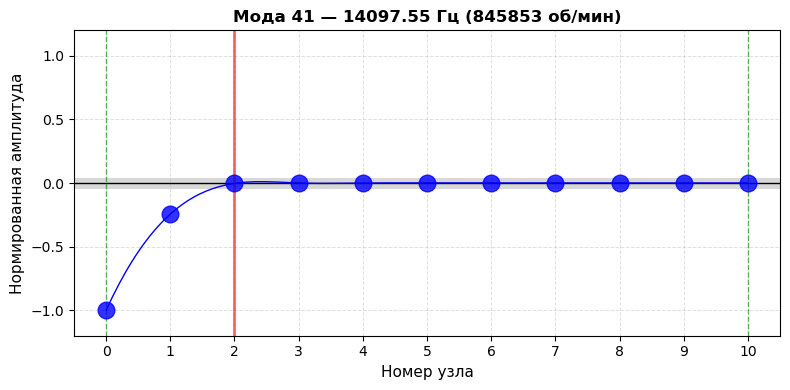

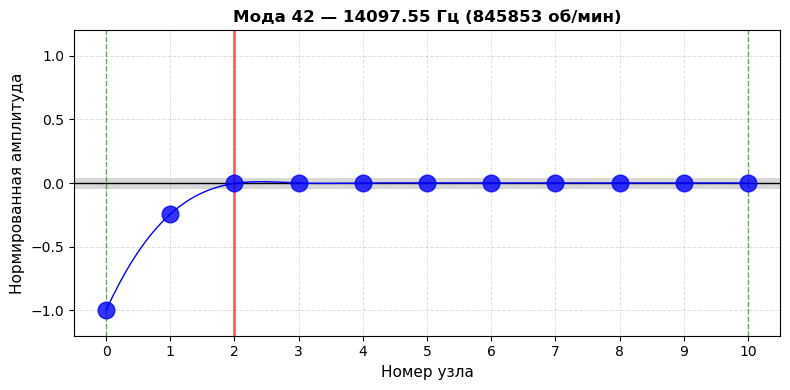

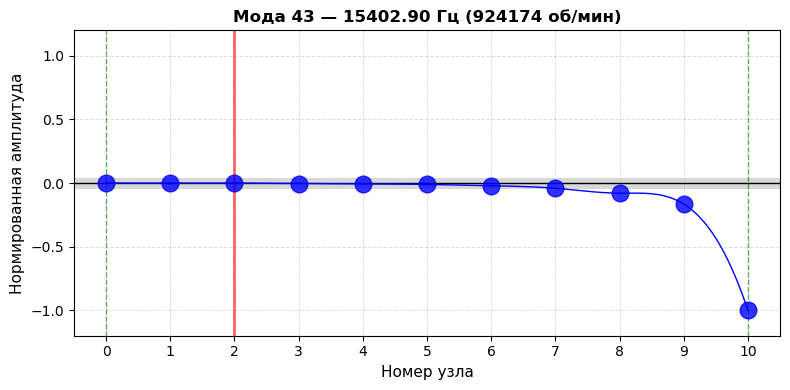

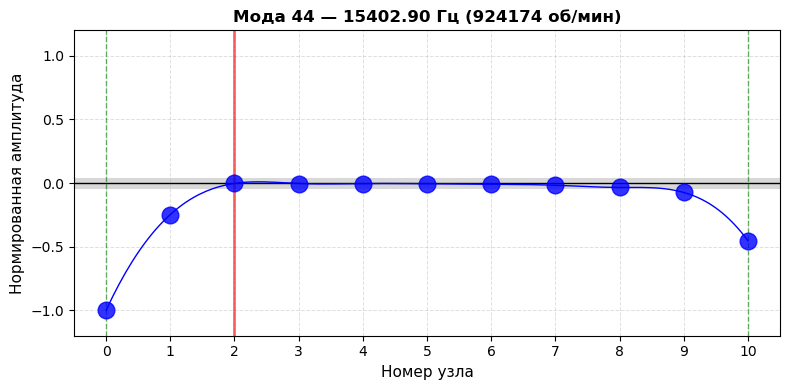


СОБСТВЕННЫЕ ЧАСТОТЫ:
------------------------------------------------------------
 Мода  Частота, Гц  Частота, об/мин
------------------------------------------------------------
    1         16.77          1006.25
    2         16.77          1006.25
    3         64.00          3839.76
    4         64.00          3839.76
    5        167.34         10040.14
    6        167.34         10040.14
    7        257.86         15471.40
    8        257.86         15471.40
    9        428.85         25730.77
   10        428.85         25730.77
   11        699.60         41975.96
   12        699.60         41975.96
  ... и еще 32 мод
Получено 44 собственных частот


In [39]:
def solve_eigen_and_plot(Kf: np.ndarray, Mf: np.ndarray, 
                         free_dofs: np.ndarray, fixed_dofs: np.ndarray,
                         n_nodes: int, Ls: float = 1.8, 
                         normalize: bool = True, scale_rot: float = 0.1,
                         save_plots: bool = False, out_dir: str = "mode_plots",
                         disk_nodes: list = None, bearing_nodes: list = None) -> tuple:
    if disk_nodes is None:
        disk_nodes = [2]
    if bearing_nodes is None:
        bearing_nodes = [0, n_nodes-1]
    
    # Проверки размерностей
    ndof = n_nodes * 4
    if Kf.shape != Mf.shape:
        raise ValueError("Матрицы Kf и Mf должны иметь одинаковую размерность")
    
    print("\n" + "=" * 60)
    print("РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ")
    print("=" * 60)
    
    # Решение обобщенной задачи на собственные значения
    eigvals, eigvecs = eigh(Kf, Mf)
    
    # Обработка собственных значений
    eigvals = np.real(eigvals)
    eigvals[eigvals < 0] = 0.0
    freqs_hz = np.sqrt(eigvals) / (2.0 * np.pi)
    freqs_rpm = freqs_hz * 60
    
    # Сортировка по частоте
    sorted_idx = np.argsort(freqs_hz)
    freqs_hz = freqs_hz[sorted_idx]
    eigvecs = eigvecs[:, sorted_idx]
    
    # Выбор уникальных мод (каждая вторая)
    unique_idx = np.arange(0, len(freqs_hz), 1)    
    n_unique = len(unique_idx)
    freqs_unique = freqs_hz[unique_idx]
    rpm_unique = freqs_rpm[unique_idx]
    
    print(f"Всего собственных частот: {len(freqs_hz)}")
    print(f"Уникальных собственных частот: {n_unique}")
    
    node_numbers = np.arange(n_nodes)           # Массив номеров узлов
    z_coords = np.linspace(0.0, Ls, n_nodes)

    # Восстановление полных форм колебаний
    full_modes = np.zeros((ndof, n_unique))
    
    for i, idx in enumerate(unique_idx):
        phi_free = eigvecs[:, idx]
        phi_full = np.zeros(ndof)
        phi_full[free_dofs] = np.real(phi_free)
        phi_full[fixed_dofs] = 0.0
        full_modes[:, i] = phi_full
    
    # Построение графиков
    if save_plots:
        import os
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)
    
    print("\nПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ")
    print("-" * 40)
    
    for i in range(n_unique):
        
        # Извлечение компонент для текущей моды
        phi_full = full_modes[:, i]
        Ux = phi_full[0::4]  # Смещения Ux
        Uy = phi_full[1::4]  # Смещения Uy
        U_amp = np.sqrt(Ux**2 + Uy**2)  # Инвариантная амплитуда |U|

        # Нормировка по выбранной величине (|U|)
        if normalize:
            max_U_amp = np.max(U_amp)
            if max_U_amp == 0:
                max_U_amp = 1.0
            Ux_norm = Ux / max_U_amp
            Uy_norm = Uy / max_U_amp
            U_amp_norm = U_amp / max_U_amp
        else:
            Ux_norm = Ux
            Uy_norm = Uy
            U_amp_norm = U_amp
        
        # Интерполяция сплайнами
        cs_Ux = CubicSpline(z_coords, Ux_norm)
        cs_Uy = CubicSpline(z_coords, Uy_norm)
        cs_U_amp = CubicSpline(z_coords, U_amp_norm)
        
        z_fine = np.linspace(0.0, Ls, 200)
        node_fine = np.linspace(0, n_nodes-1, 200)       # Для гладкого графика по номерам узлов
        
        # Создание графика
        fig, ax = plt.subplots(figsize=(8, 4))   # Уменьшенный размер

        # Отррисовка вала в исходном положении
        ax.axhline(0, color='black', linestyle='-', linewidth=1)
        ax.axhline(y=0, color='gray', linewidth=8, alpha=0.3, zorder=1)
        
        # График формы колебаний (по номерам узлов): Ux, Uy и |U|
        ax.plot(node_fine, cs_Ux(z_fine), '-', color='royalblue', linewidth=1.4, zorder=3, label='Ux')
        ax.plot(node_fine, cs_Uy(z_fine), '-', color='darkorange', linewidth=1.4, zorder=3, label='Uy')
        ax.plot(node_fine, cs_U_amp(z_fine), '-', color='purple', linewidth=1.8, zorder=3, label='|U| = sqrt(Ux² + Uy²)')
        
        # Отрисовка узлов
        ax.plot(node_numbers, Ux_norm, 'o', color='royalblue', markersize=8,
                markeredgecolor='royalblue', markeredgewidth=1, alpha=0.8, zorder=4)
        ax.plot(node_numbers, Uy_norm, 'o', color='darkorange', markersize=8,
                markeredgecolor='darkorange', markeredgewidth=1, alpha=0.8, zorder=4)
        ax.plot(node_numbers, U_amp_norm, 'o', color='purple', markersize=8,
                markeredgecolor='purple', markeredgewidth=1, alpha=0.8, zorder=4)
        
        # Настройка осей
        ax.set_xlabel('Номер узла', fontsize=11)
        ax.set_ylabel('Нормированные Ux, Uy и |U|', fontsize=11) 
        ax.set_title(f"Мода {i+1} — {freqs_unique[i]:.2f} Гц ({rpm_unique[i]:.0f} об/мин)", 
                    fontsize=12, fontweight='bold')
        
        # Сетка, привязанная к номерам узлов
        ax.set_xticks(np.arange(0, n_nodes))
        ax.set_xticklabels(np.arange(0, n_nodes))
        ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
        
        # Установка пределов по X для корректного отображения
        ax.set_xlim(-0.5, n_nodes - 0.5)
        
        # Автоматическое определение пределов по Y
        y_max = np.max(np.abs(np.concatenate([Ux_norm, Uy_norm, U_amp_norm]))) * 1.2
        if y_max == 0:
            y_max = 1.0
        ax.set_ylim(-y_max, y_max)
        
        # Вертикальные линии для диска и подшипников
        for node in disk_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='red', linestyle='-', 
                          linewidth=2, alpha=0.6, label='Диск' if node == disk_nodes[0] else "")
        
        for node in bearing_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='green', linestyle='--', 
                          linewidth=1, alpha=0.6, label='Подшипник' if node == bearing_nodes[0] else "")
                
         # Легенда для первой моды
        if i == 0 and (disk_nodes or bearing_nodes):
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)
        else:
            ax.legend(loc='upper right', fontsize=9)
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(os.path.join(out_dir, f"mode_{i+1:02d}.png"), dpi=200, bbox_inches='tight')
        
        plt.show()
        plt.close(fig)
    
    # Вывод таблицы частот
    print("\nСОБСТВЕННЫЕ ЧАСТОТЫ:")
    print("-" * 60)
    print(f"{'Мода':^6} {'Частота, Гц':^12} {'Частота, об/мин':^15}")
    print("-" * 60)
    
    for i in range(min(n_unique, 12)):
        print(f" {i+1:4d}    {freqs_unique[i]:10.2f}     {rpm_unique[i]:12.2f}")
    
    if n_unique > 12:
        print(f"  ... и еще {n_unique - 12} мод")
    
    print("=" * 60)
    
    return freqs_hz, full_modes


# Запуск решения
freqs, modes = solve_eigen_and_plot(Kf, Mf, free_dofs, fixed_dofs,
                                    n_nodes=n_nodes, Ls=Ls,
                                    normalize=True, scale_rot=0.1,
                                    save_plots=False,
                                    disk_nodes=[disk_node_idx],
                                    bearing_nodes=bearing_nodes)

print(f"Получено {len(freqs)} собственных частот")

### ПОСТРОЕНИЕ ДИАГРАММЫ КЭМПБЕЛЛА

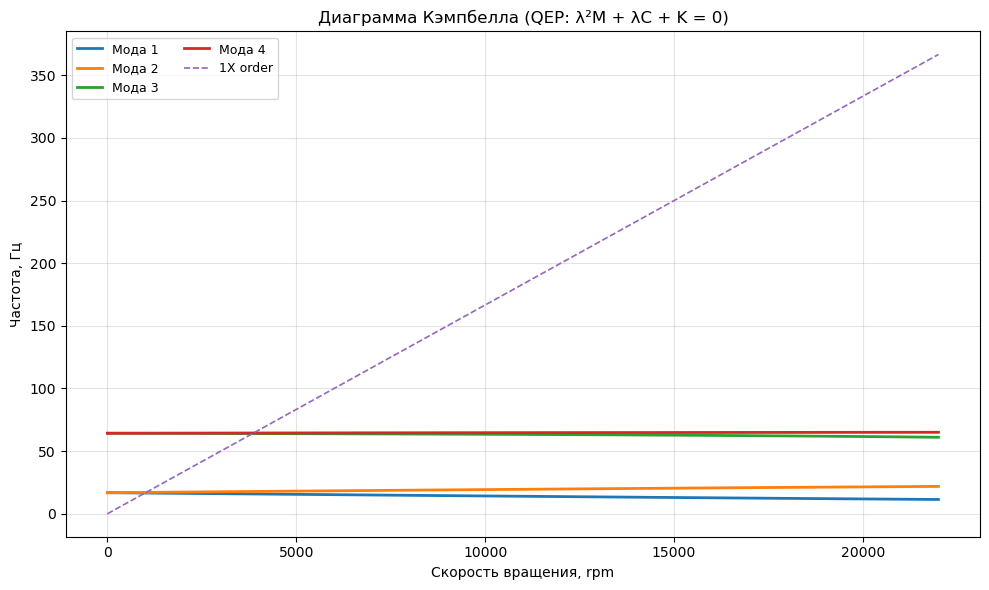

In [31]:
def qep_eigenfrequencies(M: np.ndarray, C: np.ndarray, K: np.ndarray, n_modes: int = 8) -> np.ndarray:
    """Решение квадратичной задачи: (λ²M + λC + K)φ = 0.
    Возвращает первые n_modes положительных частот (Гц).
    """
    n = M.shape[0]
    Z = np.zeros((n, n))
    I = np.eye(n)

    # Линеаризация QEP в обобщенную задачу A z = λ B z
    A = np.block([
        [Z, I],
        [-K, -C]
    ])
    B = np.block([
        [I, Z],
        [Z, M]
    ])

    lam, _ = eig(A, B)
    lam = lam[np.isfinite(lam)]

    # Для колебательных мод используем ветвь с Im(λ) > 0
    lam_pos = lam[np.imag(lam) > 1e-7]
    freqs = np.imag(lam_pos) / (2 * np.pi)
    freqs = np.real(freqs[freqs > 0])
    freqs = np.sort(freqs)

    if len(freqs) < n_modes:
        out = np.full(n_modes, np.nan)
        out[:len(freqs)] = freqs
        return out

    return freqs[:n_modes]


def build_campbell_qep(Mf: np.ndarray, Kf: np.ndarray, G0f: np.ndarray, Df: np.ndarray,
                       rpm_min: float = 0, rpm_max: float = 22000, n_points: int = 110,
                       n_modes: int = 8, n_orders: int = 4):
    rpm_grid = np.linspace(rpm_min, rpm_max, n_points)
    mode_map = np.full((n_modes, n_points), np.nan)

    for j, rpm in enumerate(rpm_grid):
        Omega = 2 * np.pi * rpm / 60.0
        C = Df + Omega * G0f
        mode_map[:, j] = qep_eigenfrequencies(Mf, C, Kf, n_modes=n_modes)

    plt.figure(figsize=(10, 6))

    # Модальные ветви
    for i in range(n_modes):
        plt.plot(rpm_grid, mode_map[i, :], linewidth=2, label=f'Мода {i+1}')

    # Линии порядков возбуждения (kX)
    for k in range(1, n_orders + 1):
        plt.plot(rpm_grid, k * rpm_grid / 60.0, '--', linewidth=1.2, label=f'{k}X order')

    plt.title('Диаграмма Кэмпбелла (QEP: λ²M + λC + K = 0)')
    plt.xlabel('Скорость вращения, rpm')
    plt.ylabel('Частота, Гц')
    plt.grid(True, alpha=0.35)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    return rpm_grid, mode_map


# Подготовка редуцированных матриц
G0f = G0[np.ix_(free_dofs, free_dofs)]
Df = D_b[np.ix_(free_dofs, free_dofs)]

rpm_grid, campbell_modes = build_campbell_qep(
    Mf=Mf,
    Kf=Kf,
    G0f=G0f,
    Df=Df,
    rpm_min=0,
    rpm_max=22000,
    n_points=110,
    n_modes=4,
    n_orders=1,
)



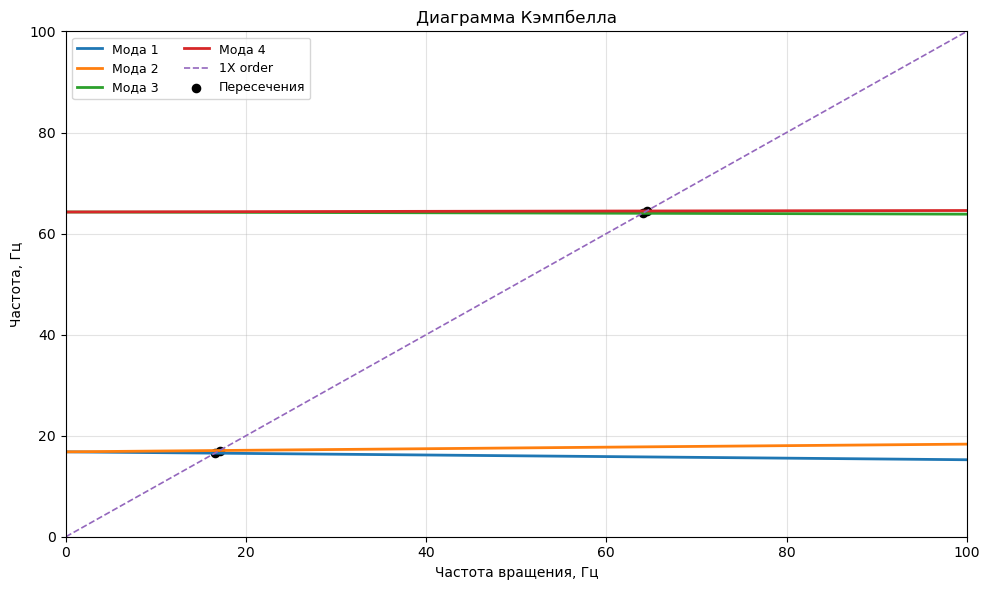

Найденные пересечения (критические скорости):
 mode  order  spin_hz  freq_hz
    1      1   16.542   16.542
    2      1   17.065   17.065
    3      1   64.017   64.017
    4      1   64.474   64.474


In [32]:
def qep_eigenfrequencies(M: np.ndarray, C: np.ndarray, K: np.ndarray, n_modes: int = 8) -> np.ndarray:
    """Решение квадратичной задачи: (λ²M + λC + K)φ = 0.
    Возвращает первые n_modes положительных частот (Гц).
    """
    n = M.shape[0]
    Z = np.zeros((n, n))
    I = np.eye(n)

    # Линеаризация QEP в обобщенную задачу A z = λ B z
    A = np.block([
        [Z, I],
        [-K, -C]
    ])
    B = np.block([
        [I, Z],
        [Z, M]
    ])

    lam, _ = eig(A, B)
    lam = lam[np.isfinite(lam)]

    # Для колебательных мод используем ветвь с Im(λ) > 0
    lam_pos = lam[np.imag(lam) > 1e-7]
    freqs = np.imag(lam_pos) / (2 * np.pi)
    freqs = np.real(freqs[freqs > 0])
    freqs = np.sort(freqs)

    if len(freqs) < n_modes:
        out = np.full(n_modes, np.nan)
        out[:len(freqs)] = freqs
        return out

    return freqs[:n_modes]


def find_mode_order_intersections(freq_grid_hz: np.ndarray, mode_map: np.ndarray, n_orders: int = 4) -> pd.DataFrame:
    """Поиск пересечений мод и порядков возбуждения методом линейной интерполяции."""
    intersections = []

    for mode_idx in range(mode_map.shape[0]):
        f_mode = mode_map[mode_idx, :]

        for order in range(1, n_orders + 1):
            f_order = order * freq_grid_hz
            diff = f_mode - f_order

            for j in range(len(freq_grid_hz) - 1):
                d1, d2 = diff[j], diff[j + 1]
                if np.isnan(d1) or np.isnan(d2):
                    continue

                # Попадание точно в узел сетки
                if np.isclose(d1, 0.0, atol=1e-10):
                    intersections.append({
                        'mode': mode_idx + 1,
                        'order': order,
                        'spin_hz': float(freq_grid_hz[j]),
                        'freq_hz': float(f_mode[j])
                    })
                    continue

                # Смена знака на интервале => есть пересечение
                if d1 * d2 < 0:
                    t = d1 / (d1 - d2)
                    freq_cross = freq_grid_hz[j] + t * (freq_grid_hz[j + 1] - freq_grid_hz[j])
                    f_cross = f_mode[j] + t * (f_mode[j + 1] - f_mode[j])
                    intersections.append({
                        'mode': mode_idx + 1,
                        'order': order,
                        'spin_hz': float(freq_cross),
                        'freq_hz': float(f_cross)
                    })

    if len(intersections) == 0:
        return pd.DataFrame(columns=['mode', 'order', 'spin_hz', 'freq_hz'])

    df = pd.DataFrame(intersections)
    df = df.sort_values(['spin_hz', 'mode', 'order']).reset_index(drop=True)
    return df


def build_campbell_qep(Mf: np.ndarray, Kf: np.ndarray, G0f: np.ndarray, Df: np.ndarray,
                        spin_hz_min: float = 0, spin_hz_max: float = 200, n_points: int = 80,
                        n_modes: int = 8, n_orders: int = 4, show_intersections: bool = True):
    freq_grid_hz = np.linspace(spin_hz_min, spin_hz_max, n_points)
    mode_map = np.full((n_modes, n_points), np.nan)

    for j, spin_hz in enumerate(freq_grid_hz):
        Omega = 2 * np.pi * spin_hz
        C = Df + Omega * G0f
        mode_map[:, j] = qep_eigenfrequencies(Mf, C, Kf, n_modes=n_modes)

    intersections_df = find_mode_order_intersections(freq_grid_hz, mode_map, n_orders=n_orders)

    plt.figure(figsize=(10, 6))

    # Модальные ветви
    for i in range(n_modes):
        plt.plot(freq_grid_hz, mode_map[i, :], linewidth=2, label=f'Мода {i+1}')

    # Линии порядков возбуждения (kX)
    for k in range(1, n_orders + 1):
        plt.plot(freq_grid_hz, k * freq_grid_hz, '--', linewidth=1.2, label=f'{k}X order')

    # Маркеры пересечений
    if show_intersections and not intersections_df.empty:
        plt.scatter(intersections_df['spin_hz'], intersections_df['freq_hz'],
                    c='black', s=35, marker='o', label='Пересечения')

    plt.xlim([0, 100])
    plt.ylim([0, 100])
    plt.title('Диаграмма Кэмпбелла')
    plt.xlabel('Частота вращения, Гц')
    plt.ylabel('Частота, Гц')
    plt.grid(True, alpha=0.35)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    if intersections_df.empty:
        print('Пересечения мод с порядками возбуждения не обнаружены на заданной сетке скоростей.')
    else:
        print('Найденные пересечения (критические скорости):')
        print(intersections_df.round({'spin_hz': 3, 'freq_hz': 3}).to_string(index=False))

    return freq_grid_hz, mode_map, intersections_df


# Подготовка редуцированных матриц
G0f = G0[np.ix_(free_dofs, free_dofs)]
Df = D_b[np.ix_(free_dofs, free_dofs)]
spin_freq_grid_hz, campbell_modes, campbell_intersections = build_campbell_qep(
    Mf=Mf,
    Kf=Kf,
    G0f=G0f,
    Df=Df,
    spin_hz_min=0,
    spin_hz_max=400,
    n_points=110,
    n_modes=4,
    n_orders=1,
    show_intersections=True,
)
    
    
